In [1]:
import os
import random
from collections import Counter, defaultdict

import numpy as np
from PIL import Image, ImageDraw, ImageFont
import pandas as pd
from matplotlib import pyplot as plt, font_manager, rcParams

from utils.path import PROJECT_ROOT

# Set random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [2]:
BASE_FONT_DIR = f"{PROJECT_ROOT}/fonts"
FONT_PATH = {
    "Noto Sans Javanese Regular": f"{BASE_FONT_DIR}/Noto_Sans_Javanese/static/NotoSansJavanese-Regular.ttf",
    "Noto Sans Javanese Bold": f"{BASE_FONT_DIR}/Noto_Sans_Javanese/static/NotoSansJavanese-Bold.ttf",
    # "Noto Sans Javanese Medium": f"{BASE_FONT_DIR}/Noto_Sans_Javanese/static/NotoSansJavanese-Medium.ttf", # DUPLICATE
    # "Noto Sans Javanese SemiBold": f"{BASE_FONT_DIR}/Noto_Sans_Javanese/static/NotoSansJavanese-SemiBold.ttf", # DUPLICATE
    # "Noto Sans Javanese Variable": f"{BASE_FONT_DIR}/Noto_Sans_Javanese/NotoSansJavanese-VariableFont_wght.ttf", # DUPLICATE
    # "AB Bakul": f"{BASE_FONT_DIR}/AB Bakul-Aditya Bayu-aksaradinusantara/AB bakul.ttf", # UNRECOGNIZED
    # "AB Wulang": f"{BASE_FONT_DIR}/AB Wulang-Aditya Bayu-aksaradinusantara/AB wulang.otf", # UNRECOGNIZED
    # "Adipati Genk": f"{BASE_FONT_DIR}/Adipati genk-Adipati Genk Kobra-aksaradinusantara/Adipati Genk.ttf", # ERROR
    # "AR Demak Beta": f"{BASE_FONT_DIR}/AR Demak-Arif Budiarto-aksaradinusantara/ARDemakbeta-Regular.ttf", # UNRECOGNIZED
    # "AR Demak Draft": f"{BASE_FONT_DIR}/AR Demak-Arif Budiarto-aksaradinusantara/Demak-draft.ttf", # ERROR
    "CARAKAN JAWA": f"{BASE_FONT_DIR}/CARAKAN JAWA-Sudarto Hs_Ki Demang Sokowaten-aksaradinusantara/CARAKAN JAWA.otf",
    # "Damarwulan": f"{BASE_FONT_DIR}/Damarwulan-Arif Budiarto-aksaradinusantara/damarwulan-bw.ttf", # UNRECOGNIZED
    # "Dhuwung": f"{BASE_FONT_DIR}/Font Dhuwung-Apri Nugroho-aksaradinusantara/File Font Aksara Jawa/DHUWUNG.ttf", # UNRECOGNIZED
    # "Genk-Kobra Elysanti": f"{BASE_FONT_DIR}/Genk Kobra Elysanti-Adipati Genk Kobra-aksaradinusantara/Genk-Kobra Elysanti rev.ttf", # ERROR
    # "Genk-Kobra Java": f"{BASE_FONT_DIR}/Genk Kobra Java-Adipati Genk Kobra-aksaradinusantara/Genk-Kobra Java rev.ttf", # ERROR
    # "Genk-Kobra Javaholic": f"{BASE_FONT_DIR}/Genk Kobra Javaholic-Adipati Genk Kobra-aksaradinusantara/Genk-Kobra Jawa rev.ttf", # ERROR
    # "Genk-Kobra JeJe": f"{BASE_FONT_DIR}/Genk Kobra JeJe-Adipati Genk Kobra-aksaradinusantara/Genk-Kobra JeJe Rev.ttf", # ERROR
    # "Genk-Kobra Ndomblong": f"{BASE_FONT_DIR}/Genk Kobra Ndomblong-Adipati Genk Kobra-aksaradinusantara/Genk-Kobra ndomblong Rev.ttf", # ERROR
    # "Gerbangpraja": f"{BASE_FONT_DIR}/Gerbangpraja Genk Kobra-Adipati Genk Kobra-aksaradinusantara/gerbangpraja.ttf", # ERROR
    # "Gumregah New": f"{BASE_FONT_DIR}/Gumregah-Apri Nugroho-aksaradinusantara/Gumregah New.ttf", # DUPLICATE
    "Gumregah New FULL": f"{BASE_FONT_DIR}/Gumregah-Apri Nugroho-aksaradinusantara/Gumregah New FULL.ttf",
    # "Jamawi": f"{BASE_FONT_DIR}/Jamawi-Arif Budiarto-aksaradinusantara/jamawi-v1r0.ttf", # UNRECOGNIZED
    # "Javabugida": f"{BASE_FONT_DIR}/Javabugida Mahayu-Ervyn Raven-aksaradinusantara/javabugida_0001.otf", # ERROR
    # "Java Genk-Kobra": f"{BASE_FONT_DIR}/Javaholic Genk-Adipati Genk Kobra-aksaradinusantara/Java Genk-Kobra Rev.ttf", # ERROR
    "Nawatura Beta": f"{BASE_FONT_DIR}/Nawatura-Aditya Bayu-aksaradinusantara/Nawatura beta.ttf",
    # "Nawatura Beta Android": f"{BASE_FONT_DIR}/Nawatura-Aditya Bayu-aksaradinusantara/Nawatura beta android2.ttf", # DUPLICATE
    "Nayaka New": f"{BASE_FONT_DIR}/Nayaka-Apri Nugroho-aksaradinusantara/Nayaka New 2022.ttf",
    "New Kramawirya": f"{BASE_FONT_DIR}/New Kramawirya-Yayat Suhiryatna-aksaradinusantara/New Kramawirya1.ttf",
    "Nyk Ngayogyan Jejeg": f"{BASE_FONT_DIR}/nyk Ngayogyan Jejeg-Apri Nugroho-aksaradinusantara/nyk Ngayogyan Jejeg.ttf",
    "Nyk Ngayogyan New Italic": f"{BASE_FONT_DIR}/nyk Ngayogyan-Apri Nugroho-aksaradinusantara/nyk Ngayogyan New Italic.ttf",
    # "Sehulbari": f"{BASE_FONT_DIR}/Sehulbari-Arif Budiarto-aksaradinusantara/Sehulbari.ttf", # UNRECOGNIZED
    "Tuladha Jejeg": f"{BASE_FONT_DIR}/Tuladha Jejeg-R. S. Wihananto-aksaradinusantara/TuladhaJejeg_gr.ttf",
    # "Djoharuddin": f"{BASE_FONT_DIR}/Djoharuddin-Aditya Bayu-aksaradinusantara.ttf", # UNRECOGNIZED
}
print("Jumlah variasi font: ", len(FONT_PATH))


# Plot font configuration
font_manager.fontManager.addfont(FONT_PATH["Noto Sans Javanese Regular"])
rcParams["font.family"] = font_manager.FontProperties(fname=FONT_PATH["Noto Sans Javanese Regular"]).get_name()


Jumlah variasi font:  10


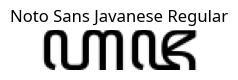

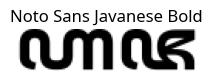

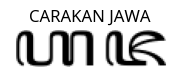

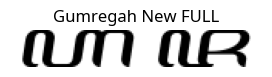

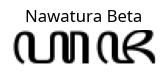

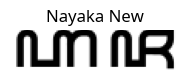

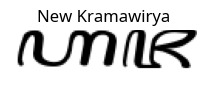

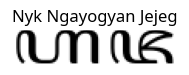

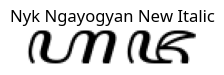

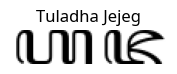

In [3]:
def plot_font_samples():
    sample_text = "ꦲꦗ"
    # sample_text = "ꦲ ꦤ ꦕ ꦫ ꦏ ꦢ ꦠ ꦱ ꦮ ꦭ ꦥ ꦝ ꦗ ꦪ ꦚ ꦩ ꦒ ꦧ ꦛ ꦔ"
    for font_name, font_path in FONT_PATH.items():
        try:
            font = ImageFont.truetype(font_path, 48)
        except Exception as e:
            print(f"Failed to load font {font_name}: {e}")
            continue

        dummy = Image.new("RGB", (1, 1))
        draw_dummy = ImageDraw.Draw(dummy)
        bbox = draw_dummy.textbbox((0, 0), sample_text, font=font)
        w = bbox[2] - bbox[0]
        h = bbox[3] - bbox[1]

        img = Image.new("RGB", (w, h), color=(255, 255, 255))
        draw = ImageDraw.Draw(img)

        draw.text((-bbox[0], -bbox[1]), sample_text, font=font, fill=(0, 0, 0))

        plt.figure(figsize=(w/50, h/50), facecolor='white')
        plt.imshow(np.array(img))
        plt.title(font_name)
        plt.axis("off")
        plt.show()


plot_font_samples()


Rendering train
Font usage in train:
New Kramawirya: 108
Tuladha Jejeg: 106
Nawatura Beta: 106
CARAKAN JAWA: 105
Nyk Ngayogyan Jejeg: 101
Nyk Ngayogyan New Italic: 101
Nayaka New: 100
Noto Sans Javanese Bold: 93
Noto Sans Javanese Regular: 90
Gumregah New FULL: 90


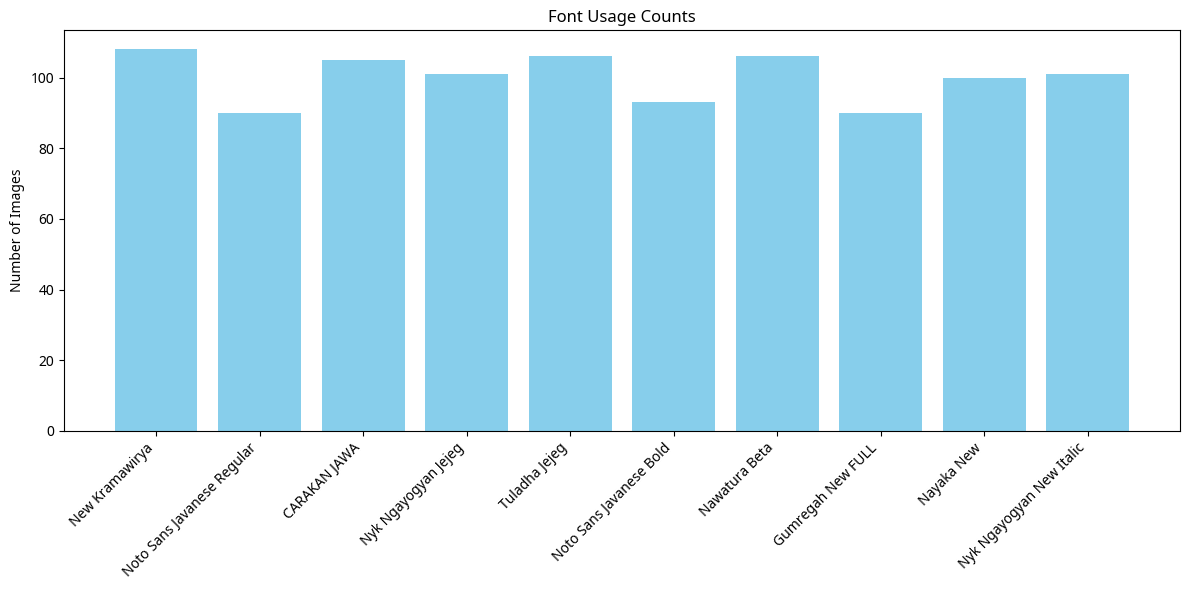

Rendering val
Font usage in val:
Noto Sans Javanese Regular: 23
Noto Sans Javanese Bold: 23
Nyk Ngayogyan Jejeg: 21
Nyk Ngayogyan New Italic: 21
New Kramawirya: 21
Nayaka New: 20
Gumregah New FULL: 20
Nawatura Beta: 19
CARAKAN JAWA: 17
Tuladha Jejeg: 15


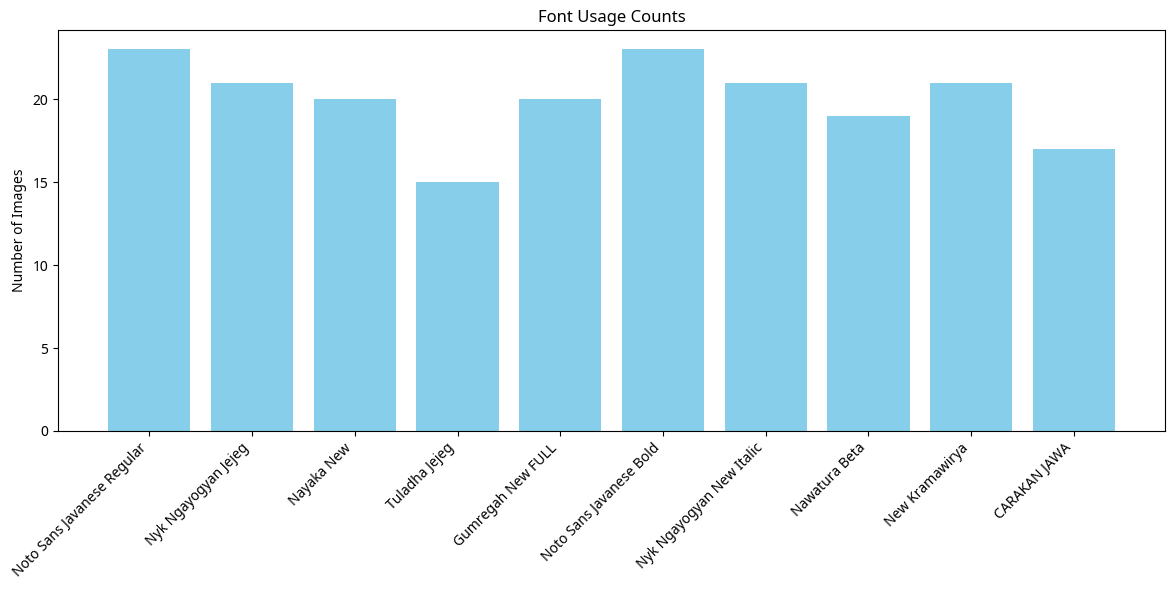

In [ ]:
def render_text(
    text: str,
    font_path: str,
    font_size: int,
    padding: int,
    target_height: int,
    bg: int = 255,
    fg: int = 0,
):
    font = ImageFont.truetype(font_path, font_size)

    dummy = Image.new("L", (1, 1), bg)
    draw_dummy = ImageDraw.Draw(dummy)
    bbox = draw_dummy.textbbox((0, 0), text, font=font)

    w = bbox[2] - bbox[0]
    h = bbox[3] - bbox[1]

    padded_w = w + 2 * padding
    padded_h = h + 2 * padding

    img = Image.new("L", (padded_w, padded_h), bg)
    draw = ImageDraw.Draw(img)
    draw.text((padding - bbox[0], padding - bbox[1]), text, fill=fg, font=font)

    scale = target_height / padded_h
    new_width = int(round(padded_w * scale))

    img = img.resize((new_width, target_height), Image.LANCZOS)

    return img


def render_dataset_from_csv(
    csv_path: str,
    img_dir: str,
    font_paths: dict,
    font_size: int,
    padding: int,
    target_height: int,
):
    os.makedirs(img_dir, exist_ok=True)
    if os.listdir(img_dir):
        raise RuntimeError(f"Directory {img_dir} is not empty")

    df = pd.read_csv(csv_path)

    font_names = list(font_paths.keys())
    font_files = list(font_paths.values())
    font_coverage = Counter()

    if "font_used" not in df.columns:
        df["font_used"] = ""

    for i, (_, row) in enumerate(df.iterrows()):
        weights = [1 / (font_coverage[f] + 1) for f in font_names]
        font_path = random.choices(font_files, weights=weights, k=1)[0]
        font_name = font_names[font_files.index(font_path)]
        font_coverage[font_name] += 1

        img = render_text(
            text=row["transcription"],
            font_path=font_path,
            font_size=font_size,
            padding=padding,
            target_height=target_height,
        )

        img.save(os.path.join(img_dir, row["image"]))
        df.at[i, "font_used"] = font_name

    df.to_csv(csv_path, index=False)

    return font_coverage



BASE_DATA_DIR = f"{PROJECT_ROOT}/dataset/word_nglegena_synthetic_20260130_155231"
splits = {
    "train": "label_train.csv",
    "val": "label_val.csv",
}

FONT_SIZE = 48 # Point
PADDING = 1 # Pixel
TARGET_HEIGHT = 48 # Pixel

for split, csv_name in splits.items():
    csv_path = os.path.join(BASE_DATA_DIR, csv_name)
    img_dir = os.path.join(BASE_DATA_DIR, f"image_{split}")

    print(f"Rendering {split}")
    coverage = render_dataset_from_csv(
        csv_path=csv_path,
        img_dir=img_dir,
        font_paths=FONT_PATH,
        font_size=FONT_SIZE,
        padding=PADDING,
        target_height=TARGET_HEIGHT,
    )

    print(f"Font usage in {split}:")
    for font, count in coverage.most_common():
        print(f"{font}: {count}")
    plt.figure(figsize=(12, 6)) 
    plt.bar(coverage.keys(), coverage.values(), color="skyblue")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Number of Images")
    plt.title("Font Usage Counts")
    plt.tight_layout()
    plt.show()


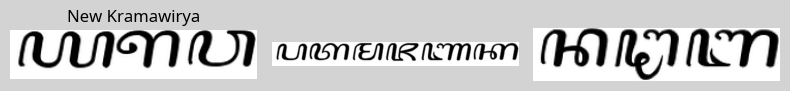

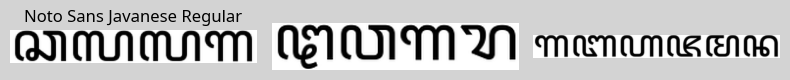

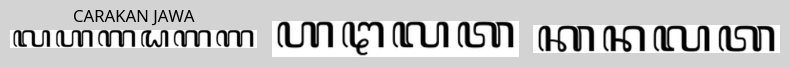

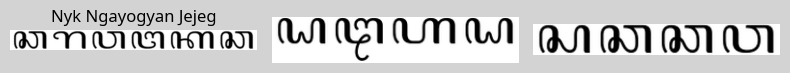

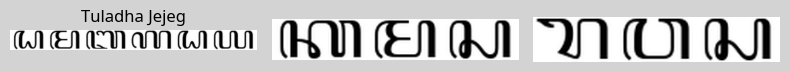

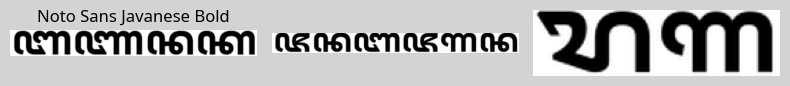

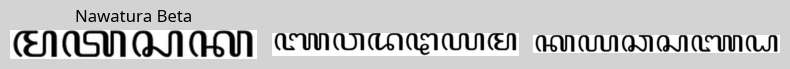

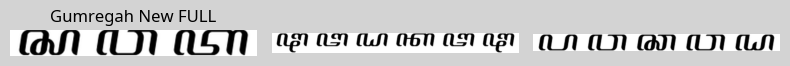

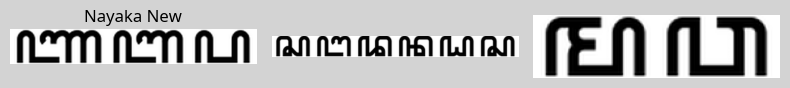

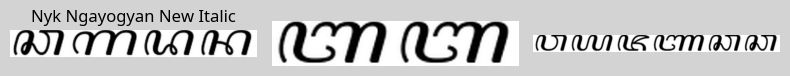

In [5]:
def visualize_font_samples(
    csv_path: str,
    image_dir: str,
    samples_per_font: int = 3,
    cmap: str = "gray",
):
    df = pd.read_csv(csv_path)

    required_cols = {"image", "font_used"}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"CSV harus mengandung kolom {required_cols}")

    font_to_images = defaultdict(list)
    for _, row in df.iterrows():
        img_path = os.path.join(image_dir, row["image"])
        if os.path.exists(img_path):
            font_to_images[row["font_used"]].append(img_path)

    for _, (font_name, img_list) in enumerate(font_to_images.items()):
        if not img_list:
            continue

        samples = random.sample(
            img_list, min(samples_per_font, len(img_list)),
        )

        plt.figure(
            figsize=(8, samples_per_font * 8),
            facecolor="lightgray"
        )

        for i, img_path in enumerate(samples):
            img = Image.open(img_path)
            ax = plt.subplot(5, samples_per_font, i + 1)
            ax.imshow(img, cmap=cmap)
            ax.axis("off")

            if i == 0:
                ax.set_title(font_name, fontsize=12)

        plt.tight_layout()
        plt.show()



visualize_font_samples(
    f"{BASE_DATA_DIR}/label_train.csv", 
    f"{BASE_DATA_DIR}/image_train", 
    3
)
